# T1 - Programação Dinâmica


**Objetivos do trabalho:** 
- estudar, implementar e analisar o algoritmo de cálculo do comprimento da Maior Subsequência Comum entre duas strings. É um dos problemas tradicionais resolvidos com Programação Dinâmica, conhecido
como **LCS** (Longest Common Subsequence, ou Maior Sub-sequência Comum). **Dadas duas Strings**, deseja-se descobrir qual o tamanho da Maior Subsequência Comum de entre S1 e S1.

### Imports

In [3]:
import pandas as pd 
import time
import matplotlib.pyplot as plt

### LCS Dinâmico

In [4]:
def lcs_dp(A, B, imprimir_matriz=False):
    m = len(A)
    n = len(B)

    inicio = time.time()

    matriz = [[0]*(n+1) for _ in range(m+1)]

    iteracoes = 0

    for i in range(1, m+1):
        matriz[i][0] = 0

    for j in range(1, n+1):
        matriz[0][j] = 0

    for i in range(1, m+1):
        for j in range(1, n+1):
            iteracoes += 1

            if A[i-1] == B[j-1]:
                custoExtra = 1
            else:
                custoExtra = 0

            matriz[i][j] = max(
                matriz[i-1][j],
                matriz[i][j-1],
                matriz[i-1][j-1] + custoExtra
            )

    fim = time.time()
    tempo_execucao = fim - inicio


    if imprimir_matriz:
        print("\nMatriz DP:")
        for linha in matriz:
            print(linha)

    return {
        "lcs": matriz[m][n],
        "iteracoes": iteracoes,
        "tempo": tempo_execucao
    }

### LCS Força Bruta - Recursivo

In [5]:
def lcs_forca_bruta(s1, s2, i, j, contador):
    contador[0] += 1 

    if i == 0 or j == 0:
        return 0

    if s1[i-1] == s2[j-1]:
        return 1 + lcs_forca_bruta(s1, s2, i-1, j-1, contador)
    else:
        return max(
            lcs_forca_bruta(s1, s2, i-1, j, contador),
            lcs_forca_bruta(s1, s2, i, j-1, contador)
        )
    

def executar_forca_bruta(s1, s2):
    contador = [0]

    inicio = time.time()
    resultado = lcs_forca_bruta(s1, s2, len(s1), len(s2), contador)
    fim = time.time()

    return {
        "lcs": resultado,
        "iteracoes": contador[0],
        "tempo": fim - inicio
    }

### Função Para Plot de Métricas

In [6]:
def comparar_algoritmos(casos):
    resultados = []

    for indice, (s1, s2) in enumerate(casos, start=1):
        fb = executar_forca_bruta(s1, s2)
        dp = lcs_dp(s1, s2)

        resultados.append({
            "Caso": indice,
            "Tamanho S1": len(s1),
            "Tamanho S2": len(s2),
            "LCS": dp["lcs"],
            "Iterações Força Bruta": fb["iteracoes"],
            "Tempo Força Bruta (s)": fb["tempo"],
            "Iterações Programação Dinâmica": dp["iteracoes"],
            "Tempo Programação Dinâmica (s)": dp["tempo"]
        })

    df = pd.DataFrame(resultados)

    df["Tempo Força Bruta (s)"] = df["Tempo Força Bruta (s)"].map(lambda x: f"{x:.6f}")
    df["Tempo Programação Dinâmica (s)"] = df["Tempo Programação Dinâmica (s)"].map(lambda x: f"{x:.6f}")


    try:
        display(df.style.set_table_styles([
            {'selector': 'th', 'props': [('font-size', '12pt'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('text-align', 'center')]}
        ]).set_caption("Comparação de Algoritmos LCS"))
    except:
        pass

    # gráfico
    plt.figure(figsize=(10, 5))
    plt.plot(df["Caso"], df["Iterações Força Bruta"].astype(float), marker="o", label="Força Bruta")
    plt.plot(df["Caso"], df["Iterações Programação Dinâmica"].astype(float), marker="o", label="Programação Dinâmica")

    plt.title("Iterações - LCS")
    plt.xlabel("Caso")
    plt.ylabel("Iterações")
    plt.legend()
    plt.grid(True)
    plt.show()

    return df

### Testes

In [7]:
casos = [
    ("ABC", "AC"),
    ("ABCBD", "BDC"),
    ("AGGTAB", "GXTXA"),
    ("ABCD", "EFGH"),
    ("ABCBDAB", "BDCAB")
]


,Caso,Tamanho S1,Tamanho S2,LCS,Iterações Força Bruta,Tempo Força Bruta (s),Iterações Programação Dinâmica,Tempo Programação Dinâmica (s)
0,1,3,2,2,5,0.000000,6,0.000000
1,2,5,3,2,30,0.000000,15,0.000000
2,3,6,5,3,245,0.000000,30,0.000000
3,4,4,4,0,139,0.000000,16,0.000000
4,5,7,5,4,32,0.000000,35,0.000000


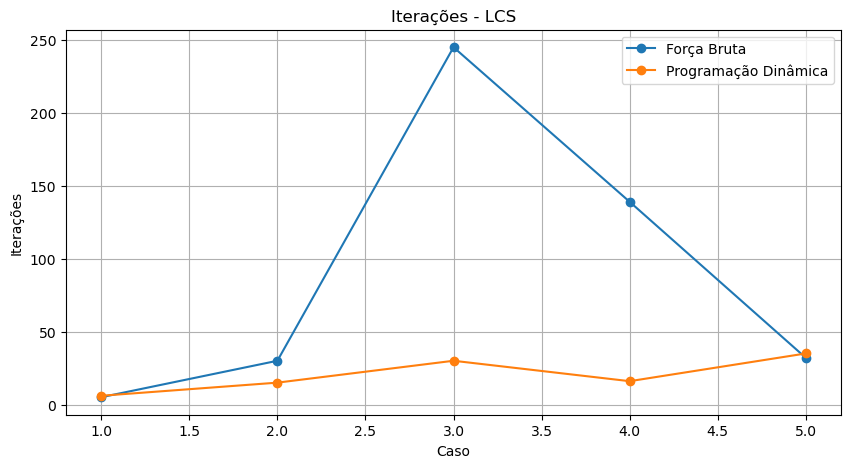

In [8]:
teste_simples = comparar_algoritmos(casos)

In [9]:
casos_pesados = [
    ("ABCDEFGH", "IJKLMNOP"),
    ("ABCDEFGHIJ", "KLMNOPQRST"),
    ("ABABABAB", "BABA"),
    ("ABABABABAB", "BABAB"),
    ("AAAAAAAAB", "BAAAAAAAA"),
    ("ABCDEF", "FABCDE"),
    ("ABCDEFGH", "HABCDEFG"),
    ("AABBAABB", "ABABABAB"),
    ("AAABBB", "ABABAB"),
    ("AAAAAAAAAA", "BBBBBBBBBB")
]

,Caso,Tamanho S1,Tamanho S2,LCS,Iterações Força Bruta,Tempo Força Bruta (s),Iterações Programação Dinâmica,Tempo Programação Dinâmica (s)
0,1,8,8,0,25739,0.012370,64,0.000000
1,2,10,10,0,369511,0.164598,100,0.000000
2,3,8,4,4,10,0.000000,32,0.000000
3,4,10,5,5,6,0.000000,50,0.000000
4,5,9,9,8,110,0.000000,81,0.000000
5,6,6,6,5,421,0.000000,36,0.000000
6,7,8,8,7,4397,0.002000,64,0.000000
7,8,8,8,6,47,0.000000,64,0.000000
8,9,6,6,4,36,0.001000,36,0.000000
9,10,10,10,0,369511,0.163752,100,0.001001


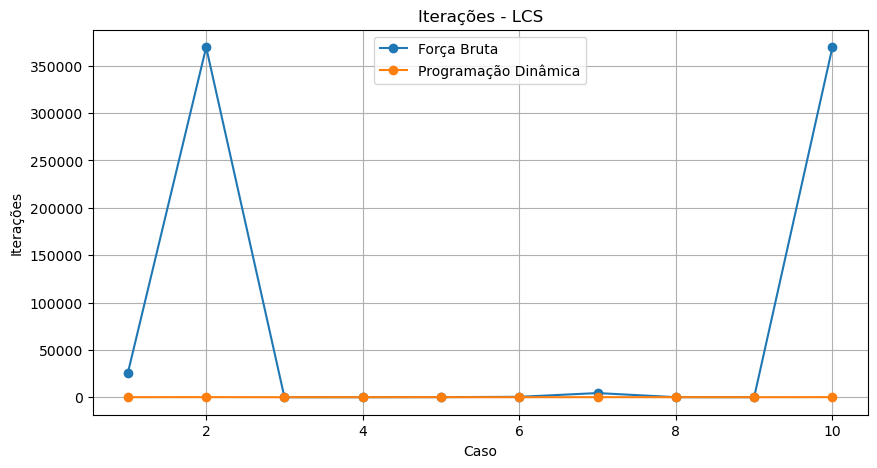

In [10]:
teste_pesado = comparar_algoritmos(casos_pesados)

In [11]:
casos_exponenciais = [
    ("ABC", "DEF"),
    ("ABCD", "EFGH"),
    ("ABCDE", "FGHIJ"),
    ("ABCDEF", "GHIJKL"),
    ("ABCDEFG", "HIJKLMN"),
    ("ABCDEFGH", "IJKLMNOP"),
    ("ABCDEFGHI", "JKLMNOPQR"),
    ("ABCDEFGHIJ", "KLMNOPQRST")
]

,Caso,Tamanho S1,Tamanho S2,LCS,Iterações Força Bruta,Tempo Força Bruta (s),Iterações Programação Dinâmica,Tempo Programação Dinâmica (s)
0,1,3,3,0,39,0.000000,9,0.000000
1,2,4,4,0,139,0.000000,16,0.000000
2,3,5,5,0,503,0.000000,25,0.000000
3,4,6,6,0,1847,0.001000,36,0.000000
4,5,7,7,0,6863,0.002997,49,0.000000
5,6,8,8,0,25739,0.012095,64,0.000000
6,7,9,9,0,97239,0.043410,81,0.000000
7,8,10,10,0,369511,0.161842,100,0.000000


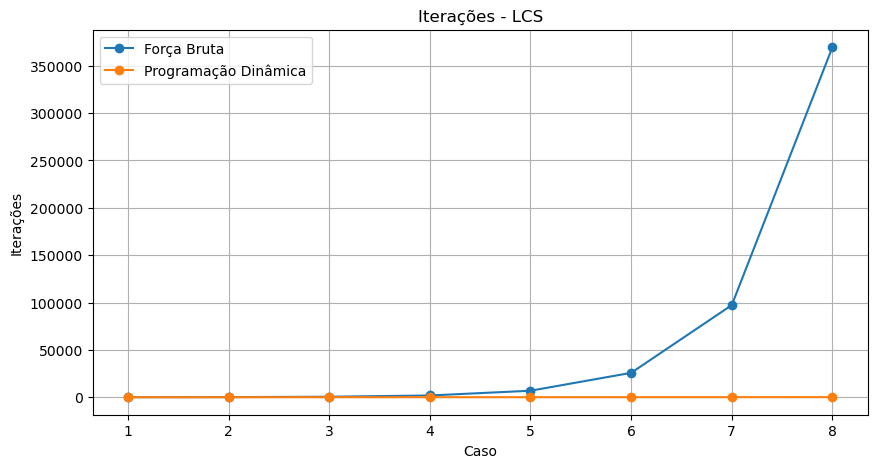

In [13]:
teste_casos_exponenciais = comparar_algoritmos(casos_exponenciais)

In [ ]:
casos_contraste = [
    ("AAAA", "AAAA"),          #melhor caso
    ("AAAAAA", "AAAAAA"),
    ("AAAAAAAA", "AAAAAAAA"),

    ("AAAA", "BBBB"),          #pior caso
    ("AAAAAA", "BBBBBB"),
    ("AAAAAAAA", "BBBBBBBB")
]

,Caso,Tamanho S1,Tamanho S2,LCS,Iterações Força Bruta,Tempo Força Bruta (s),Iterações Programação Dinâmica,Tempo Programação Dinâmica (s)
0,1,4,4,4,5,0.000000,16,0.000000
1,2,6,6,6,7,0.000000,36,0.000000
2,3,8,8,8,9,0.000000,64,0.000000
3,4,4,4,0,139,0.000000,16,0.000000
4,5,6,6,0,1847,0.000000,36,0.001513
5,6,8,8,0,25739,0.011373,64,0.000000


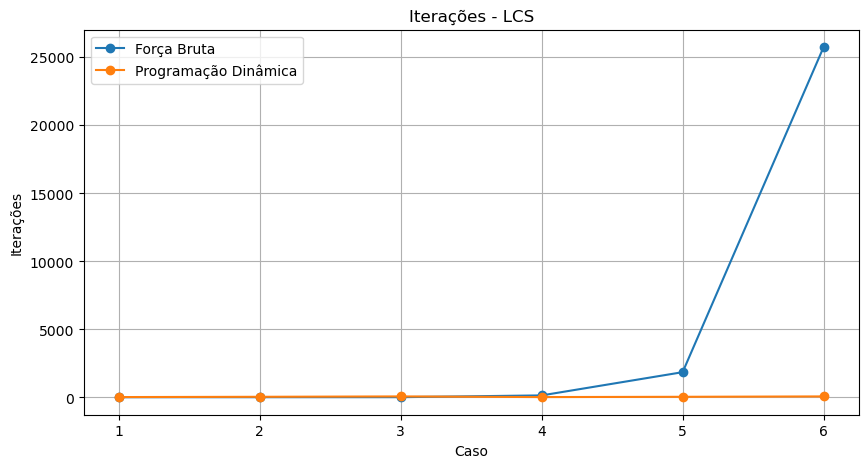

In [15]:
teste_casos_contraste = comparar_algoritmos(casos_contraste)